In [1]:
# ! python -m pip install --no-index --find-links=/kaggle/usr/lib/pip_install_permanent/my_packages -r /kaggle/usr/lib/pip_install_permanent/requirements.txt

In [14]:
# import os

# os.environ['PACKAGE_DIR'] = '/kaggle/usr/lib/pip_install_permanent'

In [2]:
from helper_func import *
# import helper_functions as hf
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import string
from spellchecker import SpellChecker
from textblob import TextBlob
from multiprocessing import Pool
from tqdm import tqdm
import numpy as np
import pandas as pd
# Preprocessing
from nltk.tokenize import word_tokenize, sent_tokenize
import operator
from spellchecker import SpellChecker
from tqdm import tqdm  # Import tqdm
import re
import inflect
from wordsegment import load, segment
from nltk.corpus import words
word_list = set(words.words())
from spellchecker import SpellChecker

from tqdm.contrib.concurrent import process_map  # If this import fails, you might need to update tqdm

import multiprocessing
 
# Import Packages
# import shutup; shutup.please()

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras_tuner as kt
import seaborn as sns

from nltk.corpus import stopwords, wordnet
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk import pos_tag, ne_chunk
from textblob import TextBlob

from textstat import flesch_reading_ease, smog_index

import spacy
from collections import Counter
from gensim import corpora, models
import pyLDAvis.gensim as gen
import pyLDAvis
import re

# Machine Learning & Data Preprocessing

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Deep Learning

from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Gensim
# from gensim.models import Word2Vec, KeyedVectors

# Progress bar
from tqdm import tqdm

# Keras Tuner
from keras_tuner.tuners import RandomSearch

# # Setting logging levels and environment variables
# tf.get_logger().setLevel(logging.ERROR)
# os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

from textstat import flesch_reading_ease
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import string
from spellchecker import SpellChecker
from textblob import TextBlob
from multiprocessing import Pool
from tqdm import tqdm
import numpy as np
import pandas as pd
# Preprocessing
from nltk.tokenize import word_tokenize, sent_tokenize
import operator
from spellchecker import SpellChecker
from tqdm import tqdm  # Import tqdm
import re
import inflect
from wordsegment import load, segment
from nltk.corpus import words
word_list = set(words.words())
print('Packages Instaled......')

/home/jack/envs/scoring/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2024-04-22 16:04:31.533698: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-04-22 16:04:32.159783: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


Packages Instaled......


[nltk_data] Downloading package punkt to /home/jack/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/jack/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package stopwords to /home/jack/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /home/jack/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [4]:
train = pd.read_csv('/home/jack/github/kaggle/scoring/data/train.csv')
train = train.sample(5)

In [5]:
# train

In [6]:
import os

glove_path = './data/glove-840B-300d.txt'

paragram_path = './data/paragram-300-sl999.txt'

wiki_news_path = './data/wiki-news-1M-300d.vec'


# Load embeddings

embeddings = parallel_load_embeddings([glove_path, paragram_path, wiki_news_path])

# glove = embeddings["glove"]
# paragram = embeddings["paragram"]
# fasttext = embeddings["fasttext"]

Loading embeddings from ./data/wiki-news-1M-300d.vecLoading embeddings from ./data/glove-840B-300d.txtLoading embeddings from ./data/paragram-300-sl999.txt




Reading Embedding File: 999995it [00:33, 30044.32it/s]]


Loaded embeddings from ./data/wiki-news-1M-300d.vec


Reading Embedding File: 1703756it [00:56, 30065.60it/s]


Loaded embeddings from ./data/paragram-300-sl999.txt


Reading Embedding File: 2196017it [01:11, 30678.55it/s]


Loaded embeddings from ./data/glove-840B-300d.txt


In [9]:
train.reset_index(drop=True, inplace=True)

In [10]:
train, glove, paragram, fastetxt = spellcheck_and_correct_text(train, embeddings)

Starting text cleaning process. 

Mis-spelling Count................. 

Checking Vocabulary................. 

Processing dataset.
Building vocabulary.


Populating Vocabulary: 100%|██████████| 5/5 [00:00<00:00, 20301.57it/s]


Vocabulary built.
Checking coverage.


Checking Words: 100%|██████████| 494/494 [00:00<00:00, 1690037.66it/s]


Coverage checked.
Checking coverage.


...

Coverage checked.
Checking coverage.


Checking Words: 100%|██████████| 510/510 [00:00<00:00, 1527925.03it/s]

Coverage checked.
Processed dataset.



100%|██████████| 20/20 [00:02<00:00,  6.73it/s]


Correcting Mis-spelling after segmentation................. 

Adding Text Features................. 

Complete................. 



In [11]:
train.head()

,essay_id,full_text,score,lowered,clean_text,misspelling_count,corrected_text,segmented_text,glove_vec_0,glove_vec_1,...,min_paragraph_length,avg_sentence_length,max_sentence_length,min_sentence_length,avg_word_length,max_word_length,min_word_length,flesch_reading_ease,gunning_fog_index,sentiment_score
3,e05e602,Luke's point of view in this story is telling ...,2,luke's point of view in this story is telling ...,lukes point of view in this story is telling p...,6,luke s point of view in this story is telling ...,luke s point of view in this story is telling ...,-0.003324,0.092373,...,169,169.0,169,169,3.840237,9,1,-66.23,67.84,0.9568
0,82b38aa,"In "" the challenge of Exploring Venus,"" the au...",1,"in "" the challenge of exploring venus,"" the au...",in the challenge of exploring venus the author...,5,in the challenge of exploring venus the author...,in the challenge of exploring venus the author...,0.002691,0.153686,...,215,215.0,215,215,4.702326,12,1,-129.84,88.98,0.8928
1,381900c,Driverless Cars?\n\nDriverless cars? I am not ...,4,driverless cars?\n\ndriverless cars? i am not ...,driverless cars driverless cars i am not so su...,5,driverless cars driverless cars i am not so su...,driverless cars driverless cars i am not so su...,-0.011401,0.078731,...,392,392.0,392,392,3.918367,10,1,-292.57,157.82,-0.9945
4,f0d7b60,"The Electoral College is outdated, unfair, and...",4,"the electoral college is outdated, unfair, and...",the electoral college is outdated unfair and i...,20,the electoral college is outdated unfair and i...,the electoral college is outdated unfair and i...,-0.002528,0.117289,...,382,382.0,382,382,4.361257,15,1,-299.34,155.52,0.9577
2,f95baca,I claim that the author explained well about s...,3,i claim that the author explained well about s...,i claim that the author explained well about s...,10,i claim that the author explained well about s...,i claim that the author explained well about s...,-0.024585,0.202120,...,429,429.0,429,429,4.617716,14,1,-347.05,174.02,0.9772


In [ ]:
# glove

In [ ]:
# len(train.columns)

In [12]:
train_essays, val_essays = custom_train_validation_split(train, test_size=0.25, random_state=42)

In [42]:
# train_essays.to_parquet('train_essays.parquet')
# val_essays.to_parquet('validation_essays.parquet')
# train.to_parquet('train_(pre-split).parquet')

In [13]:
import pandas as pd

# train_essays = pd.read_parquet('/home/jack/github/kaggle/scoring/train_essays.parquet')
# val_essays = pd.read_parquet('/home/jack/github/kaggle/scoring/validation_essays.parquet')
train_essays.reset_index(drop=True, inplace=True)
val_essays.reset_index(drop=True, inplace=True)


In [14]:
def get_dense_vector(text, embeddings, embedding_type):
    """
    Compute a dense vector representation for a given text based on a specific embedding type.
    
    :param text: The text to convert to a dense vector.
    :param embeddings: Dictionary containing embedding objects for GloVe, Paragram, and FastText.
    :param embedding_type: The embedding type to use (e.g., 'glove', 'paragram', 'fasttext').
    :return: A dense vector representing the text.
    """
    words = text.split()
    word_vectors = []

    # Aggregate vectors for known words of the specific embedding type
    for word in words:
        if word in embeddings[embedding_type]:
            word_vectors.append(embeddings[embedding_type][word])

    # If there are no word vectors, return a zero vector
    if not word_vectors:
        return np.zeros(len(list(embeddings[embedding_type].values())[0]))

    # Return the mean of the word vectors as the dense vector representation
    return np.mean(word_vectors, axis=0)

In [15]:
# Step 8: Add dense vector embeddings for each row of text as separate columns
dense_vectors = {
    'glove': train_essays['corrected_text'].apply(lambda x: get_dense_vector(x, embeddings, 'glove')),
    'paragram': train_essays['corrected_text'].apply(lambda x: get_dense_vector(x, embeddings, 'paragram')),
    'fasttext': train_essays['corrected_text'].apply(lambda x: get_dense_vector(x, embeddings, 'fasttext'))
}

# Expand the dense vectors into separate columns for each embedding type
glove_df = pd.DataFrame(list(dense_vectors['glove']), columns=[f"glove_vec_{i}" for i in range(dense_vectors['glove'][0].size)])
paragram_df = pd.DataFrame(list(dense_vectors['paragram']), columns=[f"paragram_vec_{i}" for i in range(dense_vectors['paragram'][0].size)])
fasttext_df = pd.DataFrame(list(dense_vectors['fasttext']), columns=[f"fasttext_vec_{i}" for i in range(dense_vectors['fasttext'][0].size)])

# Concatenate these new DataFrames with the original DataFrame
train = pd.concat([train_essays, glove_df, paragram_df, fasttext_df], axis=1)

In [16]:
train

,essay_id,full_text,score,lowered,clean_text,misspelling_count,corrected_text,segmented_text,glove_vec_0,glove_vec_1,...,fasttext_vec_290,fasttext_vec_291,fasttext_vec_292,fasttext_vec_293,fasttext_vec_294,fasttext_vec_295,fasttext_vec_296,fasttext_vec_297,fasttext_vec_298,fasttext_vec_299
0,e05e602,Luke's point of view in this story is telling ...,2,luke's point of view in this story is telling ...,lukes point of view in this story is telling p...,6,luke s point of view in this story is telling ...,luke s point of view in this story is telling ...,-0.003324,0.092373,...,0.005998,-0.014798,-0.000631,0.008841,-0.007944,-0.003949,-0.034374,0.174150,0.000615,-0.012746
1,381900c,Driverless Cars?\n\nDriverless cars? I am not ...,4,driverless cars?\n\ndriverless cars? i am not ...,driverless cars driverless cars i am not so su...,5,driverless cars driverless cars i am not so su...,driverless cars driverless cars i am not so su...,-0.011401,0.078731,...,0.023550,-0.017772,-0.000898,-0.012177,-0.002575,-0.011454,-0.023366,0.168973,0.023399,-0.017907
2,f0d7b60,"The Electoral College is outdated, unfair, and...",4,"the electoral college is outdated, unfair, and...",the electoral college is outdated unfair and i...,20,the electoral college is outdated unfair and i...,the electoral college is outdated unfair and i...,-0.002528,0.117289,...,0.002468,-0.014849,-0.014873,0.005122,-0.009857,-0.010063,-0.020840,0.137464,0.015471,-0.011349


In [57]:
train = train_essays.copy()

In [58]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity


# Focus on dense vectors for KMeans and PCA
dense_vector_columns = [col for col in train.columns if "vec_" in col]

# Apply KMeans clustering
kmeans = KMeans(n_clusters=3)
cluster_labels = kmeans.fit_predict(train[dense_vector_columns])
train["cluster"] = cluster_labels  # Retain original feature columns

# Apply PCA
pca = PCA(n_components=3)  # Reduce to 2 principal components
principal_components = pca.fit_transform(train[dense_vector_columns])
train["PCA_1"] = principal_components[:, 0]
train["PCA_2"] = principal_components[:, 1]
train["PCA_3"] = principal_components[:, 2]

# Compute cosine similarity for all pairs of essays
cosine_similarity_matrix = cosine_similarity(train[dense_vector_columns])

# Create a cosine similarity DataFrame with essay_id as index and columns
similarity_df = pd.DataFrame(
    cosine_similarity_matrix,
    index=train["essay_id"],
    columns=train["essay_id"]
)

# Add average cosine similarity as a feature to the original DataFrame
# train["cosine_similarity_avg"] = similarity_df.mean(axis=1)

print("Updated Training Data:")


Updated Training Data:


In [59]:
train.head()

,essay_id,full_text,score,lowered,clean_text,misspelling_count,corrected_text,segmented_text,dense_vec_0,dense_vec_1,dense_vec_2,dense_vec_3,dense_vec_4,dense_vec_5,dense_vec_6,dense_vec_7,dense_vec_8,dense_vec_9,dense_vec_10,dense_vec_11,dense_vec_12,dense_vec_13,dense_vec_14,dense_vec_15,dense_vec_16,dense_vec_17,dense_vec_18,dense_vec_19,dense_vec_20,dense_vec_21,dense_vec_22,dense_vec_23,dense_vec_24,dense_vec_25,dense_vec_26,dense_vec_27,dense_vec_28,dense_vec_29,dense_vec_30,dense_vec_31,dense_vec_32,dense_vec_33,dense_vec_34,dense_vec_35,dense_vec_36,dense_vec_37,dense_vec_38,dense_vec_39,dense_vec_40,dense_vec_41,dense_vec_42,dense_vec_43,dense_vec_44,dense_vec_45,dense_vec_46,dense_vec_47,dense_vec_48,dense_vec_49,dense_vec_50,dense_vec_51,dense_vec_52,dense_vec_53,dense_vec_54,dense_vec_55,dense_vec_56,dense_vec_57,dense_vec_58,dense_vec_59,dense_vec_60,dense_vec_61,dense_vec_62,dense_vec_63,dense_vec_64,dense_vec_65,dense_vec_66,dense_vec_67,dense_vec_68,dense_vec_69,dense_vec_70,dense_vec_71,dense_vec_72,dense_vec_73,dense_vec_74,dense_vec_75,dense_vec_76,dense_vec_77,dense_vec_78,dense_vec_79,dense_vec_80,dense_vec_81,dense_vec_82,dense_vec_83,dense_vec_84,dense_vec_85,dense_vec_86,dense_vec_87,dense_vec_88,dense_vec_89,dense_vec_90,dense_vec_91,dense_vec_92,dense_vec_93,dense_vec_94,dense_vec_95,dense_vec_96,dense_vec_97,dense_vec_98,dense_vec_99,dense_vec_100,dense_vec_101,dense_vec_102,dense_vec_103,dense_vec_104,dense_vec_105,dense_vec_106,dense_vec_107,dense_vec_108,dense_vec_109,dense_vec_110,dense_vec_111,dense_vec_112,dense_vec_113,dense_vec_114,dense_vec_115,dense_vec_116,dense_vec_117,dense_vec_118,dense_vec_119,dense_vec_120,dense_vec_121,dense_vec_122,dense_vec_123,dense_vec_124,dense_vec_125,dense_vec_126,dense_vec_127,dense_vec_128,dense_vec_129,dense_vec_130,dense_vec_131,dense_vec_132,dense_vec_133,dense_vec_134,dense_vec_135,dense_vec_136,dense_vec_137,dense_vec_138,dense_vec_139,dense_vec_140,dense_vec_141,dense_vec_142,dense_vec_143,dense_vec_144,dense_vec_145,dense_vec_146,dense_vec_147,dense_vec_148,dense_vec_149,dense_vec_150,dense_vec_151,dense_vec_152,dense_vec_153,dense_vec_154,dense_vec_155,dense_vec_156,dense_vec_157,dense_vec_158,dense_vec_159,dense_vec_160,dense_vec_161,dense_vec_162,dense_vec_163,dense_vec_164,dense_vec_165,dense_vec_166,dense_vec_167,dense_vec_168,dense_vec_169,dense_vec_170,dense_vec_171,dense_vec_172,dense_vec_173,dense_vec_174,dense_vec_175,dense_vec_176,dense_vec_177,dense_vec_178,dense_vec_179,dense_vec_180,dense_vec_181,dense_vec_182,dense_vec_183,dense_vec_184,dense_vec_185,dense_vec_186,dense_vec_187,dense_vec_188,dense_vec_189,dense_vec_190,dense_vec_191,dense_vec_192,dense_vec_193,dense_vec_194,dense_vec_195,dense_vec_196,dense_vec_197,dense_vec_198,dense_vec_199,dense_vec_200,dense_vec_201,dense_vec_202,dense_vec_203,dense_vec_204,dense_vec_205,dense_vec_206,dense_vec_207,dense_vec_208,dense_vec_209,dense_vec_210,dense_vec_211,dense_vec_212,dense_vec_213,dense_vec_214,dense_vec_215,dense_vec_216,dense_vec_217,dense_vec_218,dense_vec_219,dense_vec_220,dense_vec_221,dense_vec_222,dense_vec_223,dense_vec_224,dense_vec_225,dense_vec_226,dense_vec_227,dense_vec_228,dense_vec_229,dense_vec_230,dense_vec_231,dense_vec_232,dense_vec_233,dense_vec_234,dense_vec_235,dense_vec_236,dense_vec_237,dense_vec_238,dense_vec_239,dense_vec_240,dense_vec_241,dense_vec_242,dense_vec_243,dense_vec_244,dense_vec_245,dense_vec_246,dense_vec_247,dense_vec_248,dense_vec_249,dense_vec_250,dense_vec_251,dense_vec_252,dense_vec_253,dense_vec_254,dense_vec_255,dense_vec_256,dense_vec_257,dense_vec_258,dense_vec_259,dense_vec_260,dense_vec_261,dense_vec_262,dense_vec_263,dense_vec_264,dense_vec_265,dense_vec_266,dense_vec_267,dense_vec_268,dense_vec_269,dense_vec_270,dense_vec_271,dense_vec_272,dense_vec_273,dense_vec_274,dense_vec_275,dense_vec_276,dense_vec_277,dense_vec_278,dense_vec_279,dense_vec_280,dense_vec_281,dense_vec_282,dense_vec_283,dense_vec_284,dense_vec_285,dense_vec_286

In [60]:
similarity_df

essay_id,6744a28,6745144,6747056,674d254,6751494,67547f2,6755b68,6755e88,6759515,6770d94,678631b,678af37,678d7d6,67990fd,679b451,67b0ded,67bbfa5,67c0531,67c9586,67cf4cf,67e1c77,67edd82,67fcadc,68012ae,680c26b,680d445,681190f,6828721,682b513,682f691,6831c65,68427ee,6847e18,6852e97,6858eb1,685b699,6861f05,6862c30,6865fed,6870667,68796bc,68814ce,688168b,688b494,688ce5d,688f7ae,688fdbb,68a22c3,68b12db,68b3d6f,68b6530,68b8475,68b898b,68c21d6,68c37d4,68c44da,68c7ab1,68dab53,68eaf9f,68eb7fd,68f7f6e,68fa125,69065dc,69084e9,69128c4,691a37f,691ef51,691f21e,6920fef,692a8e5,693ed63,6942868,6943ce3,694d203,6951784,69527a4,6953953,6954731,6959d73,69654af,6969618,69715eb,6972b2f,69769d8,6979b76,6988509,69890f9,698fc7b,69911a2,699c331,699ce8c,69a1180,69d4bd8,69dbdef,69ddf90,69dfcda,69e3274,69e41e7,69e8f9e,69e9bd2,69ef9eb,69f0465,69f1da6,69f310c,69f6608,69f77d8,69fd284,6a0cbec,6a0e77b,6a13512,6a14c3d,6a18fc8,6a20b37,6a30d2a,6a30fc8,6a33f83,6a3ad47,6a3b34a,6a3b773,6a43464,6a4ff38,6a506f2,6a5a5ad,6a5d75d,6a638b1,6a736aa,6a83431,6a88483,6a88ff3,6a92849,6a970f5,6a9fa03,6aac645,6ab7d0a,6abe373,6ac4c2a,6ac9dc2,6ad33dd,6ad5505,6ad8ce5,6ada9ce,6adb60a,6ae08c7,6ae7907,6aeb5e8,6aebd9d,6aec058,6aeda00,6aeffd6,6af0db6,6af86c9,6afe275,6aff675,6b00aa5,6b02148,6b02476,6b08619,6b08f37,6b1490f,6b1c3b0,6b207f2,6b22795,6b29e4e,6b2b7d4,6b327c0,6b3ba23,6b3f030,6b445e4,6b49ba5,6b4e56f,6b51c4c,6b57a15,6b5807d,6b5cb41,6b5cecd,6b626c6,6b68b37,6b6ce58,6b6da28,6b6de98,6b6e638,6b71179,6b750b2,6b78b40,6b80d53,6b85385,6b97c5f,6b9b211,6b9b40e,6b9e3c2,6b9febe,6ba40d5,6ba8ec4,6badd4e,6bb33f3,6bc585a,6bd20d5,6bd29f5,6bd3ac7,6bd6591,6bd66b3,6bd8e65,6bddec6,6beaab6,6beb899,6bf0065,6bf05a5,6bf2b8d,6bf664d,6bfcb0e,6c11596,6c1d134,6c209af,6c22e4f,6c309ce,6c35427,6c3a92e,6c3e2b9,6c4019a,6c409c4,6c49de7,6c4d482,6c557af,6c56dcd,6c5966a,6c636c4,6c67d75,6c6ca59,6c6efec,6c73910,6c762a7,6c80131,6c84f16,6c878f6,6c8d81c,6c90c1d,6c96e47,6c991ab,6c99aa8,6c9f26e,6c9fb6f,6ca477c,6ca4a58,6ca9542,6cbe737,6cbfa0b,6cc5bef,6cc889f,6ccda33,6cd064e,6cd0f65,6cf31b1,6cf5ae1,6cf845a,6cfd94f,6d0b106,6d19518,6d23209,6d24baf,6d26aa9,6d2adc4,6d3ed36,6d3fda7,6d41232,6d50443,6d62876,6d69401,6d696a5,6d6f110,6d719a6,6d738b8,6d7892f,6d7e9e0,6d869af,6d893ff,6d8da85,6d94442,6d96038,6db09d8,6dc1f12,6dc2f1b,6dc6b0a,6dc736a,6dcc16c,6dd916e,6de1d9f,6dee91b,6df56fa,6df9eae,6dfd8bf,6dfe424,6e0482c,6e06652,6e1af01,6e29395,6e29e23,6e2aa67,6e2d013,6e33b3a,6e37111,6e3eec8,6e41a57,6e41e6f,6e46eb2,6e4cd94,6e54de4,6e59238,6e64d71,6e6ea11,6e79fe9,6e8053a,6e80f55,6e84049,6e86c83,6e89a9f,6e990ee,6e9ba8b,6e9e53e,6ea3842,6ead7d4,6eb71fc,6eb9060,6ebd28f,6ebd8ca,6ebfedc,6ec8d64,6ed0346,6ed1d58,6ed8d86,6ed94f5,6ed964d,6ed9bb3,6edf6de,6ee0571,6eecf35,6ef2063,6ef257d,6ef3220,6ef582f,6efef30,6f05de3,6f08227,6f109fd,6f15dae,6f1773b,6f1d082,6f280f2,6f30b0c,6f33e1d,6f371e5,6f37696,6f38206,6f38e1a,6f3bcc5,6f3bdb3,6f3dc33,6f470e8,6f47cd6,6f4a57d,6f4d54b,6f51437,6f62ee5,6f65bbb,6f70a6c,6f741db,6f74878,6f7c6f1,6f7f3f7,6f8353a,6f8372d,6f88292,6f8a68e,6f97075,6f9cf41,6fa61fd,6fa9527,6fad7e0,6fb25b4,6fb7a97,6fb84c0,6fb873a,6fbb921,6fc0e42,6fc833f,6fc893c,6fcd793,6fd79d3,6fdced4,6fe17cd,6fe2f23,6fe4eb5,6fe9ea7,6fecbec,6ff53a2,7006ed1,700baa8,7012c1c,7015381,7016205,701924d,70207b5,7023d2d,702ca03,70348bd,703515b,7035dc2,7036074,7036f2d,703ac27,7044865,704a88b,704ca8c,70509cc,70542b0,7056339,7057eb6,705b7fb,705d0a0,7060c69,7061185,7063170,706a54e,706d693,707366a,7077598,707b978,7082c02,708eea4,7090fb2,7094f7e,7099582,709e39a,70a621a,70a84ef,70abb34,70ad9b7,70ae282,70ae3fd,70b24ac,70b3ce0,70bb147,70cf70a,70daa75,70e0201,70e2f22,70e622a,70ec8b3,71077d8,7108253,710b137,710f583,710f5d9,7119d0f,71208a0,7123d48,7126e0c,71272ff,7136a44,713df60,713dfda,7144371,7146020,7148891,7148bb6,7148e04,714a2c3,715a7f6,716b03a,716b63f,716bea4,7173c41,717fb16,71845df,71846cc,718bcde,718ee5b,71905fe,71956aa,719648c,719aa38,719c6f1,719e49f,71a1944,71a568d,71a67d7,71aa653,71aaa97,71aefb8,71b6e79,71b9fec,71bc28b,71c12b0,71c1f3d,71c4a6d,71c9986,71ced58,71d3076,71d8782,71e1055

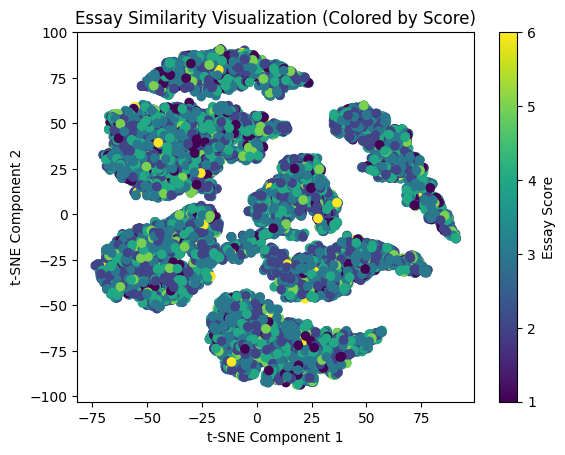

In [61]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Apply t-SNE to the similarity matrix to reduce to 2D
tsne = TSNE(n_components=2)
similarity_2d = tsne.fit_transform(similarity_df)

# Create a new DataFrame for visualization
visualization_df = pd.DataFrame({
    "x": similarity_2d[:, 0],
    "y": similarity_2d[:, 1],
    "score": train["score"]
})

# Visualize with a scatter plot, colored by essay score
plt.scatter(visualization_df["x"], visualization_df["y"], c=visualization_df["score"], cmap="viridis")
plt.colorbar(label="Essay Score")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.title("Essay Similarity Visualization (Colored by Score)")
plt.show()


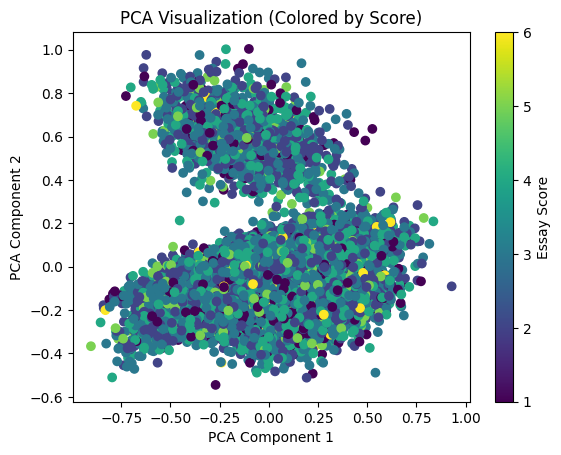

In [62]:
# Visualize PCA with a scatter plot, colored by essay score
plt.scatter(train["PCA_1"], train["PCA_2"], c=train["score"], cmap="viridis")
plt.colorbar(label="Essay Score")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("PCA Visualization (Colored by Score)")
plt.show()

In [63]:
import pandas as pd
from sklearn.utils import resample

def sample_df(df, col='score', sub=0, random_state=None):
    """
    Balances the classes in a DataFrame by resampling.
    
    Parameters:
    - df: DataFrame to be resampled.
    - col: The column name in df that contains class labels.
    - random_state: The random state for reproducibility.
    
    Returns:
    - balanced_df: A DataFrame with balanced classes.
    """
    class_counts = df[col].value_counts()
    target_count = max(int(class_counts.median()) - sub, class_counts.min())  # Ensure target_count is positive
    
    balanced_df = pd.DataFrame()

    for class_label in df[col].unique():
        class_subset = df[df[col] == class_label]
        
        if len(class_subset) > target_count:
            # Downsample majority classes
            class_subset = resample(class_subset,
                                    replace=False,
                                    n_samples=target_count,
                                    random_state=random_state)
        else:
            # Upsample minority classes
            class_subset = resample(class_subset,
                                    replace=True,
                                    n_samples=target_count,
                                    random_state=random_state)
        
        balanced_df = pd.concat([balanced_df, class_subset], axis=0)
    
    # Shuffle the DataFrame to mix the classes well
    balanced_df = balanced_df.sample(frac=1, random_state=random_state).reset_index(drop=True)

    return balanced_df


In [64]:
UPSAMPLE = True

if UPSAMPLE:
    
    # Balance only the training DataFrame
    train_essays = sample_df(train_essays, col='score', random_state=42, sub=0)

    
else:
    pass

In [65]:
print(train_essays['score'].value_counts())
print(val_essays['score'].value_counts())

score
2    1948
1    1948
4    1948
5    1948
3    1948
6    1948
Name: count, dtype: int64
score
3    1590
2    1176
4     987
1     295
5     242
6      37
Name: count, dtype: int64


In [1]:
train_essays.columns

NameError: name 'train_essays' is not defined

In [67]:
drop_cols = [ 'full_text', 'lowered', 'clean_text','corrected_text', 'segmented_text']


train_df = train_essays.copy()
val_df = val_essays.copy()

train_df.drop(columns=drop_cols, inplace= True)
val_df.drop(columns=drop_cols, inplace= True)


In [68]:
feature_cols = []

for col in train_df.columns:
    if (col != 'essay_id') and (col != 'score'):
        feature_cols.append(col)

In [71]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import pickle

# Assuming 'feature_cols' are defined elsewhere in your script

# Labels (stays the same)
train_labels = train_df['score']
val_labels = val_df['score']



# Features
train_features = train_df[feature_cols]
val_features = val_df[feature_cols]


# Initialize scaler
scaler = StandardScaler()

# Fit scaler to the original full training data
scaler.fit(train_features)

# Transform all datasets using the fitted scaler
train_feats_scaled = scaler.transform(train_features)
val_feats_scaled = scaler.transform(val_features)


# Save the scaler for later use
with open('tf_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)


In [72]:
# Check if the file has been written correctly and is not empty
import os
scaler_path = 'tf_scaler.pkl'
if os.path.getsize(scaler_path) > 0:
    print(f"Scaler saved successfully in {scaler_path}.")
else:
    print(f"Failed to save scaler to {scaler_path}. File is empty.")

Scaler saved successfully in tf_scaler.pkl.


In [73]:
import tensorflow as tf

# Assuming train_labels and val_labels are your label arrays with classes 1-6

train_labels_one_hot = tf.keras.utils.to_categorical(train_labels - 1, num_classes=6)
val_labels_one_hot = tf.keras.utils.to_categorical(val_labels - 1, num_classes=6)


In [74]:
# Log shapes right before the fit call
print("Training features shape:", train_feats_scaled.shape)
print("Training labels shape:", train_labels_one_hot.shape)
print("Validation features shape:", val_feats_scaled.shape)
print("Validation labels shape:", val_labels_one_hot.shape)


Training features shape: (11688, 316)
Training labels shape: (11688, 6)
Validation features shape: (4327, 316)
Validation labels shape: (4327, 6)


In [75]:
# import tensorflow as tf

# train_class = tf.data.Dataset.from_tensor_slices((train_feats_scaled, 
#                                                 train_labels_one_hot)).batch(32)

# val_class = tf.data.Dataset.from_tensor_slices((val_feats_scaled, 
#                                               val_labels_one_hot)).batch(32)

In [76]:
# from sklearn.utils import class_weight

# class_weights = class_weight.compute_class_weight('balanced', classes=np.unique(train_labels), y=train_labels)
# class_weights_dict = {i: weight for i, weight in enumerate(class_weights)}

# class_weights

In [77]:
import tensorflow as tf
import numpy as np

def quadratic_weighted_kappa(y_true, y_pred):
    """
    Calculates the Quadratic Weighted Kappa (QWK) aka Cohen's Kappa with quadratic weights.
    
    Parameters:
    y_true (tensor): The ground truth labels as one-hot encoded vectors.
    y_pred (tensor): The predicted probability distributions.
    
    Returns:
    float: The QWK score.
    """
    # Convert predictions to class indices
    y_pred_classes = tf.argmax(y_pred, axis=-1)
    y_pred_one_hot = tf.one_hot(y_pred_classes, depth=y_true.shape[-1])

    # Calculate the confusion matrix
    confusion_matrix = tf.math.confusion_matrix(tf.argmax(y_true, axis=1), y_pred_classes, num_classes=y_true.shape[-1])

    # Normalize the confusion matrix
    confusion_matrix = tf.cast(confusion_matrix, dtype=tf.float32)
    confusion_matrix = confusion_matrix / tf.reduce_sum(confusion_matrix)

    # Calculate weights
    num_classes = tf.shape(confusion_matrix)[0]
    weights = tf.cast(tf.range(num_classes), dtype=tf.float32) / tf.cast(num_classes - 1, dtype=tf.float32)
    weights = tf.square(tf.expand_dims(weights, -1) - tf.expand_dims(weights, 0))

    # Calculate the observed and expected agreement
    observed = tf.reduce_sum(weights * confusion_matrix)
    expected = tf.reduce_sum(
        weights * tf.matmul(
            tf.reshape(tf.reduce_sum(confusion_matrix, axis=1), [-1, 1]),
            tf.reshape(tf.reduce_sum(confusion_matrix, axis=0), [1, -1])
        )
    )

    # Calculate the kappa score
    kappa = 1.0 - observed / expected
    return kappa

In [78]:
import tensorflow as tf
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.optimizers import schedules, AdamW, RMSprop

def build_classification_model(hp, input_shape=(train_feats_scaled.shape[1],)):
    
    n_hidden = hp.Int("n_hidden", min_value=0, max_value=8, default=2)  # number of hidden layers
    n_neurons = hp.Int("n_neurons", min_value=16, max_value=256)  # neurons in each hidden layer
    l2_reg = hp.Float("l2_reg", min_value=1e-6, max_value=1e-2, sampling="log")  # L2 regularization
    learning_rate = hp.Float("learning_rate", min_value=1e-4, max_value=1e-2, sampling="log")  # learning rate

    optimizer_choice = hp.Choice("optimizer_choice", ['adam', 'sgd', 'RMSprop', 'Adagrad', 'Adadelta', 'Nadam', 'Ftrl', 'L-BFGS'])

    # Learning rate schedulers
    lr_schedule = schedules.ExponentialDecay(initial_learning_rate=learning_rate,
                                             decay_steps=10000,
                                             decay_rate=0.9)

    if optimizer_choice == 'adam':
        optimizer = AdamW(learning_rate=lr_schedule)
    elif optimizer_choice == 'sgd':
        optimizer = tf.keras.optimizers.SGD(learning_rate=lr_schedule)
    elif optimizer_choice == 'RMSprop':
        optimizer = RMSprop(learning_rate=lr_schedule)
    elif optimizer_choice == 'Adagrad':
        optimizer = tf.keras.optimizers.Adagrad(learning_rate=lr_schedule)
    elif optimizer_choice == 'Adadelta':
        optimizer = tf.keras.optimizers.Adadelta(learning_rate=lr_schedule)
    elif optimizer_choice == 'Nadam':
        optimizer = tf.keras.optimizers.Nadam(learning_rate=lr_schedule)
    else:
        optimizer = tf.keras.optimizers.Ftrl(learning_rate=lr_schedule)

    model = tf.keras.models.Sequential()

    # Input layer
    model.add(tf.keras.Input(shape=input_shape))  # Explicit input layer

    model.add(tf.keras.layers.Dense(n_neurons, 
                                    activation='relu', 
                                    kernel_regularizer=tf.keras.regularizers.l2(l2_reg)))

    dropout_rate = hp.Float("dropout_rate", min_value=0.0, max_value=0.5, step=0.05)  # dropout rate

    # Hidden layers with Batch Normalization and Dropout
    for _ in range(n_hidden):
        model.add(tf.keras.layers.BatchNormalization())
        
        model.add(tf.keras.layers.Dense(n_neurons, 
                                        activation='relu', 
                                        kernel_regularizer=tf.keras.regularizers.l2(l2_reg)))
        
        model.add(tf.keras.layers.Dropout(rate=dropout_rate))

    # Output layer for 6 classes
    model.add(tf.keras.layers.Dense(6, activation='softmax'))
    
    
    
#     from tensorflow.keras.metrics import AUC

#     # For binary classification
#     roc_auc = AUC(curve='ROC')

#     # For multi-class classification (assuming one-vs-all approach)
#     roc_auc_multi = AUC(curve='ROC', multi_label=True, num_labels=6)




    # Then, you can add it to your model's compile method as a metric
    model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=[ 
                       tf.keras.metrics.CategoricalAccuracy(),
                       tf.keras.metrics.F1Score( average='weighted'),
                       tf.keras.metrics.AUC(curve='ROC', multi_label=True, num_labels=6),
                       quadratic_weighted_kappa])


    # Learning rate reduction callback
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-5)

    return model



from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import keras_tuner as kt

model_checkpoint = ModelCheckpoint('data/models/best_standard_model_epoch.keras', 
                                   save_best_only=True, monitor='val_loss', mode='min')

early_stopping = EarlyStopping(monitor='val_loss', patience=5, 
                               restore_best_weights=True)

call_backs = [model_checkpoint, early_stopping]

tuner = kt.BayesianOptimization(
    build_classification_model,
    objective='val_loss',
    max_trials=20,
    num_initial_points= 5,
    seed=1,
    overwrite=True,
    directory='data/models/tuner_2',
    project_name='standard',
)

tuner.search(train_feats_scaled, train_labels_one_hot, epochs=1000, 
             validation_data= (val_feats_scaled, val_labels_one_hot), callbacks = call_backs, verbose=2)      # class_weight=class_weights_dict,



Trial 20 Complete [00h 01m 10s]
val_loss: 1.3457355499267578

Best val_loss So Far: 1.1796196699142456
Total elapsed time: 00h 13m 03s


In [79]:
best_standard_model = tuner.get_best_models(num_models=1)[0]

In [80]:
best_standard_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        81,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 82,694 (323.02 KB)

 Trainable params: 82,694 (323.02 KB)

 Non-trainable params: 0 (0.00 B)

In [81]:
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
model = tuner.hypermodel.build(best_hps)
history = model.fit(train_feats_scaled, train_labels_one_hot, 
                    epochs=1000, batch_size=32, 
                    callbacks = call_backs, verbose=2, validation_data= (val_feats_scaled, val_labels_one_hot))

Epoch 1/1000
366/366 - 2s - 4ms/step - auc_1: 0.7521 - categorical_accuracy: 0.3207 - f1_score: 0.2275 - loss: 1.5615 - quadratic_weighted_kappa: 0.6508 - val_auc_1: 0.8259 - val_categorical_accuracy: 0.2078 - val_f1_score: 0.2054 - val_loss: 1.5073 - val_quadratic_weighted_kappa: 0.4139
Epoch 2/1000
366/366 - 0s - 1ms/step - auc_1: 0.8515 - categorical_accuracy: 0.4605 - f1_score: 0.4392 - loss: 1.1898 - quadratic_weighted_kappa: 0.8098 - val_auc_1: 0.8314 - val_categorical_accuracy: 0.3589 - val_f1_score: 0.3796 - val_loss: 1.3153 - val_quadratic_weighted_kappa: 0.5744
Epoch 3/1000
366/366 - 0s - 1ms/step - auc_1: 0.8687 - categorical_accuracy: 0.5149 - f1_score: 0.5071 - loss: 1.0883 - quadratic_weighted_kappa: 0.8325 - val_auc_1: 0.8302 - val_categorical_accuracy: 0.3980 - val_f1_score: 0.4137 - val_loss: 1.2665 - val_quadratic_weighted_kappa: 0.6006
Epoch 4/1000
366/366 - 0s - 1ms/step - auc_1: 0.8791 - categorical_accuracy: 0.5469 - f1_score: 0.5421 - loss: 1.0354 - quadratic_wei

366/366 - 1s - 1ms/step - auc_1: 0.9235 - categorical_accuracy: 0.6820 - f1_score: 0.6775 - loss: 0.7811 - quadratic_weighted_kappa: 0.8927 - val_auc_1: 0.8239 - val_categorical_accuracy: 0.4620 - val_f1_score: 0.4707 - val_loss: 1.2008 - val_quadratic_weighted_kappa: 0.6299
Epoch 16/1000
366/366 - 0s - 1ms/step - auc_1: 0.9257 - categorical_accuracy: 0.6900 - f1_score: 0.6857 - loss: 0.7681 - quadratic_weighted_kappa: 0.8962 - val_auc_1: 0.8234 - val_categorical_accuracy: 0.4490 - val_f1_score: 0.4628 - val_loss: 1.2113 - val_quadratic_weighted_kappa: 0.6247


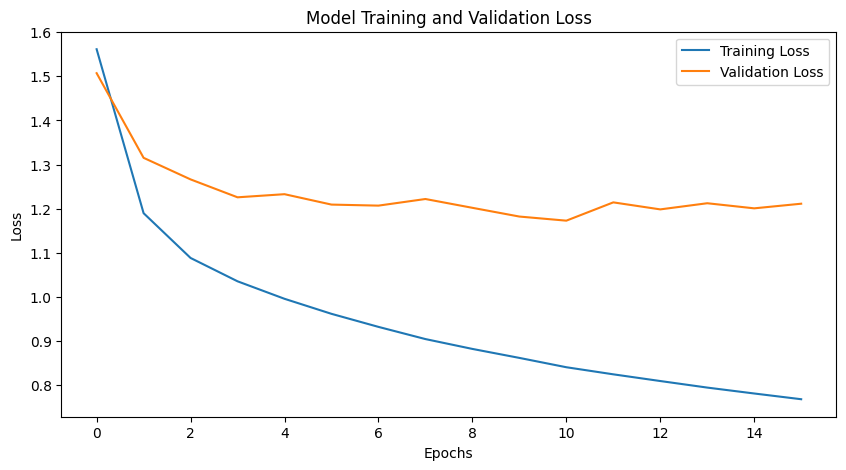

In [82]:
import matplotlib.pyplot as plt

# Assuming you have a history object from model.fit()
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [83]:
# Evaluate the model on the validation dataset

results = model.evaluate(x = val_feats_scaled, y = val_labels_one_hot , verbose=0)

# Print all results

print(results)

[1.1729027032852173, 0.8309469223022461, 0.47608041763305664, 0.4868663549423218, 0.6406348943710327]


In [84]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Assuming val_reg is your validation dataset
# Extract true labels and convert from one-hot encoding to integer labels if necessary
y_true = np.argmax(val_labels_one_hot, axis=1)


if y_true.ndim > 1 and y_true.shape[1] > 1:  # Check if y_true is one-hot encoded
    y_true = np.argmax(y_true, axis=1)

# Predict the classes with the best model on the validation data

y_pred = model.predict(val_feats_scaled)

y_pred_classes = np.argmax(y_pred, axis=1)  # Convert from probabilities to class labels

y_pred_classes = y_pred_classes + 1



136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 552us/step


In [85]:
# Compute the confusion matrix

cm = confusion_matrix(y_true, y_pred_classes)
cm

array([[  0,  98, 133,  43,  17,   4,   0],
       [  0, 251, 616, 241,  58,  10,   0],
       [  0, 178, 324, 701, 314,  63,  10],
       [  0,  17,   9, 264, 485, 192,  20],
       [  0,   0,   0,   3,  57, 147,  35],
       [  0,   0,   0,   0,   1,  23,  13],
       [  0,   0,   0,   0,   0,   0,   0]])

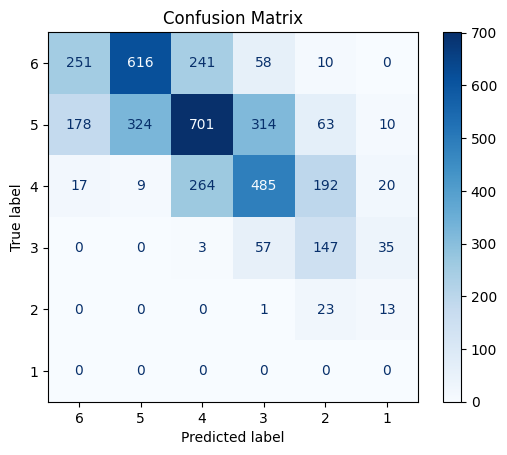

In [86]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate and display the confusion matrix for the test predictions
cm = confusion_matrix(y_true, y_pred_classes, labels=sorted(val_labels.unique()))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(val_labels.unique(), reverse=True))
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

In [87]:
print(sorted(val_labels.unique()))
print(sorted(pd.Series(y_pred_classes).unique()))

[1, 2, 3, 4, 5, 6]
[1, 2, 3, 4, 5, 6]


In [88]:
from sklearn.metrics import cohen_kappa_score

# Calculate the Quadratic Weighted Kappa

qwk_score = cohen_kappa_score(y_true, y_pred_classes, weights='quadratic')

print("Quadratic Weighted Kappa score:", qwk_score)

Quadratic Weighted Kappa score: 0.4704369379333848


In [89]:
model.save('best_classification_model.keras')

# Train on full unbalanced data

In [ ]:
print(full_train_feats_scaled.shape, full_train_labels_one_hot.shape)
print(sampled_train_feats_scaled.shape,sampled_train_labels_one_hot.shape)

In [ ]:
# best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

full_model = tuner.hypermodel.build(best_hps)
full_history = model.fit(full_train_feats_scaled, full_train_labels_one_hot, 
                    epochs=1000, batch_size=32, 
                    callbacks = call_backs, verbose=2, validation_data= (full_val_feats_scaled, full_val_labels_one_hot))

In [ ]:
import matplotlib.pyplot as plt

# Assuming you have a history object from model.fit()

plt.figure(figsize=(10, 5))
plt.plot(full_history.history['loss'], label='Training Loss')
plt.plot(full_history.history['val_loss'], label='Validation Loss')
plt.title('Model Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [ ]:
# Evaluate the model on the validation dataset

full_results = full_model.evaluate(x = full_val_feats_scaled, y = full_val_labels_one_hot , verbose=0)

# Print all results

print(results)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Assuming val_reg is your validation dataset

# Extract true labels and convert from one-hot encoding to integer labels if necessary
full_y_true = np.argmax(full_val_labels_one_hot, axis=1)

if full_y_true.ndim > 1 and full_y_true.shape[1] > 1:  # Check if y_true is one-hot encoded
    full_y_true = np.argmax(full_y_true, axis=1)

# Predict the classes with the best model on the validation data

full_y_pred = full_model.predict(full_val_feats_scaled)

full_y_pred_classes = np.argmax(full_y_pred, axis=1)  # Convert from probabilities to class labels

# Compute the confusion matrix
full_cm = confusion_matrix(full_y_true, full_y_pred_classes)

# Plotting the confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(full_cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [ ]:
full_model.save('full_best_classification_model.keras')